**SECTION 01 IMPORT LIBRARIES**

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

**SECTION 02 LOAD DATASET**

In [ ]:
df = pd.read_csv("cleaned_accessibility_dataset.csv")
df.head()

,Location_ID,Location_Name,Location_Type,City,State,Latitude,Longitude,Ownership_Type,Building_Age_Years,Last_Renovation_Years_Ago,...,Complaint_Resolution_Days,Accessibility_Complaints,User_Rating,Google_Maps_Rating,Last_Inspection_Months,Lift_Condition,Emergency_Exit_Accessibility,Accessibility_Score,Accessibility_Category,Improvement_Priority
0,LOC0001,Kolkata Botanical Garden,8,13,14,22.691764,88.446606,1,168,32.0,...,13.0,3,1.8,1.8,12.0,1,1,47.2,Poor,Medium
1,LOC0002,Hyderabad Municipal Office,3,8,12,17.236120,78.585714,1,57,12.0,...,12.0,3,1.9,1.8,15.0,1,0,36.1,Poor,High
2,LOC0003,Thane Government College,2,22,9,19.107785,73.081622,1,48,20.0,...,17.0,6,1.6,1.5,12.0,2,2,50.3,Poor,High
3,LOC0004,Nashik Green Park,6,18,9,19.849054,73.865693,1,38,22.0,...,21.0,5,3.2,3.1,12.0,1,1,38.2,Poor,High
4,LOC0005,Patna Domestic Airport,0,19,2,25.647041,85.202726,1,5,5.0,...,10.0,4,4.4,4.3,18.0,1,2,100.0,Excellent,Low


**SECTION 03 DATASET OVERVIEW**

In [ ]:
print("="*50)
print("DATASET SHAPE")
print("="*50)
print(df.shape)

print("\n")

print("="*50)
print("DATA TYPES")
print("="*50)
print(df.dtypes)

print("\n")

print("="*50)
print("MISSING VALUES")
print("="*50)
print(df.isnull().sum())

print("\n")

print("="*50)
print("DUPLICATES")
print("="*50)
print(df.duplicated().sum())

DATASET SHAPE
(1000, 43)


DATA TYPES
Location_ID                      object
Location_Name                    object
Location_Type                     int64
City                              int64
State                             int64
Latitude                        float64
Longitude                       float64
Ownership_Type                    int64
Building_Age_Years                int64
Last_Renovation_Years_Ago       float64
Number_of_Floors                  int64
Ramp_Available                    int64
Elevator_Available                int64
Wheelchair_Entrance               int64
Braille_Signage                   int64
Audio_Announcements               int64
Accessible_Washroom               int64
Tactile_Path                      int64
Reserved_Parking                  int64
Door_Width_cm                   float64
Footpath_Condition                int64
Lighting                          int64
Safety_Level                      int64
CCTV_Available                    int64
St

**SECTION 04 STATISTICAL SUMMARY**

In [ ]:
df.describe().T

df.describe(include = "object").T

,count,unique,top,freq
Location_ID,1000,1000,LOC1000,1
Location_Name,1000,594,Guwahati Collectorate Office,6
Accessibility_Category,1000,4,Poor,430
Improvement_Priority,1000,3,High,445


**SECTION 05 ACCESSIBILITY SCORE DISTRIBUTION**

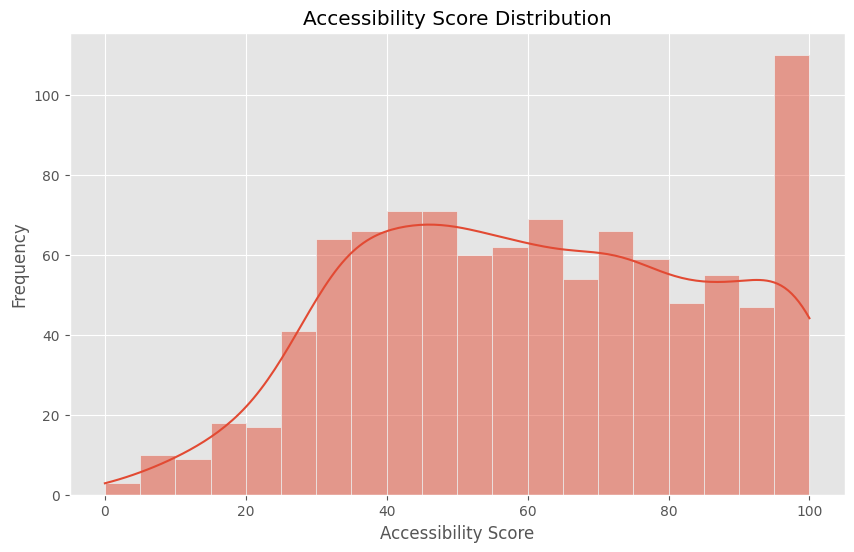

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(df["Accessibility_Score"], bins=20, kde=True)

plt.title("Accessibility Score Distribution")
plt.xlabel("Accessibility Score")
plt.ylabel("Frequency")
plt.show()

**SECTION 06 ACCESSIBILITY CATEGORY**

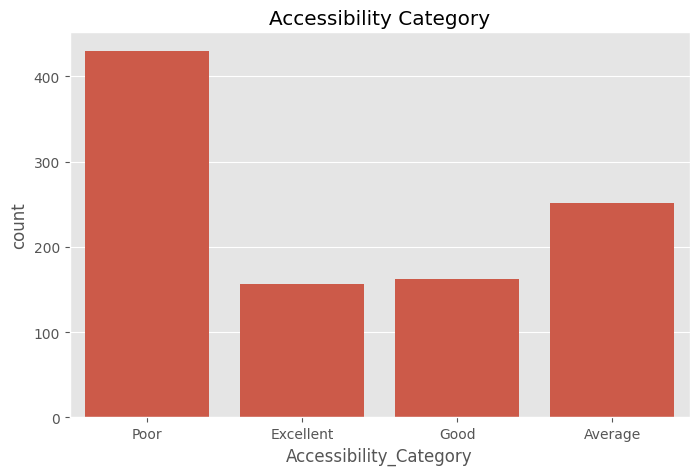

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(x="Accessibility_Category", data=df)
plt.title("Accessibility Category")
plt.show()

**SECTION 07 LOCATION TYPE DISTRIBUTION**

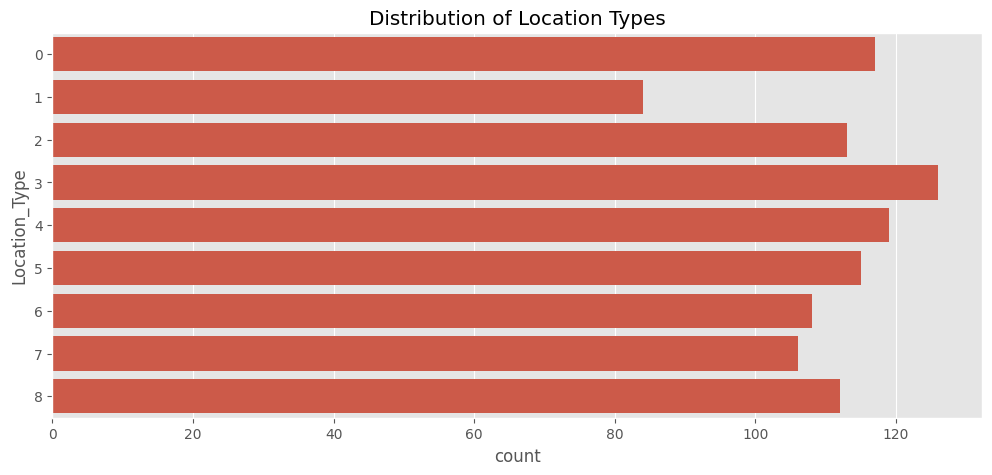

In [ ]:
plt.figure(figsize=(12,5))

sns.countplot(y="Location_Type", data=df)
plt.title("Distribution of Location Types")
plt.show()

**SECTION 08 CROWD LEVEL**

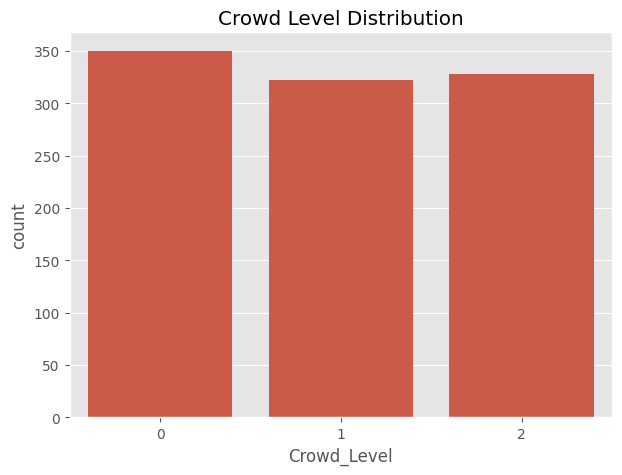

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(x="Crowd_Level", data=df)
plt.title("Crowd Level Distribution")
plt.show()

**SECTION 09 SAFETY LEVEL**

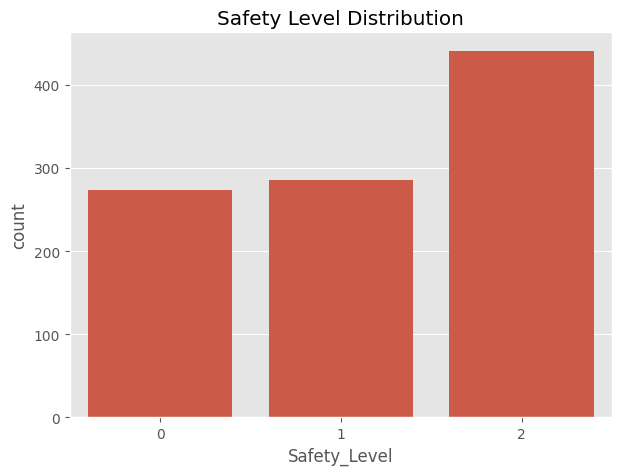

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(x="Safety_Level", data=df)
plt.title("Safety Level Distribution")
plt.show()

**SECTION 10 LIGHTING**

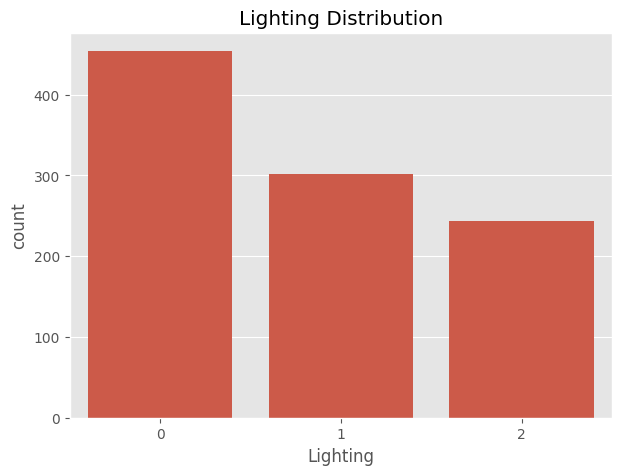

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(x="Lighting", data=df)
plt.title("Lighting Distribution")
plt.show()

**SECTION 11 USER RATING**

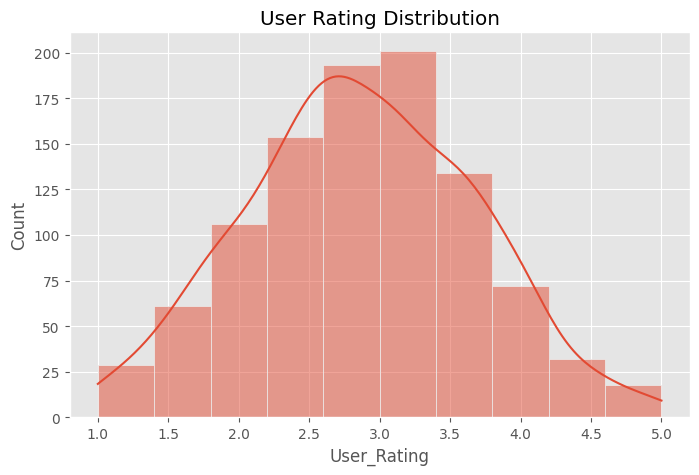

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df["User_Rating"], bins=10, kde=True)
plt.title("User Rating Distribution")
plt.show()

**SECTION 12 COMPLAINTS**

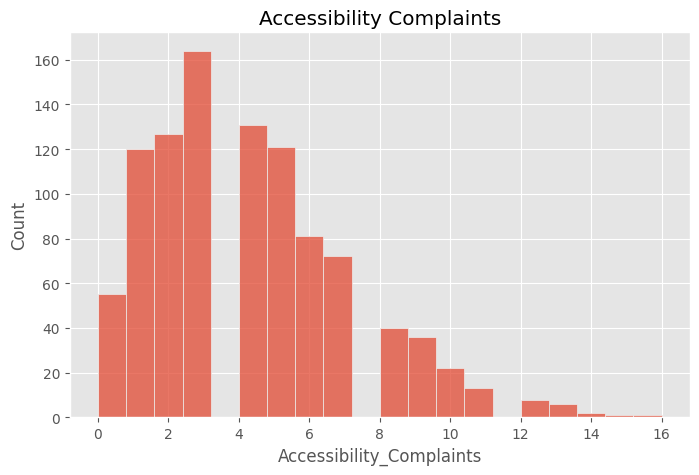

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df["Accessibility_Complaints"], bins=20)
plt.title("Accessibility Complaints")
plt.show()

**SECTION 13 ACCESSIBILITY SCORE BY LOCATION TYPE**

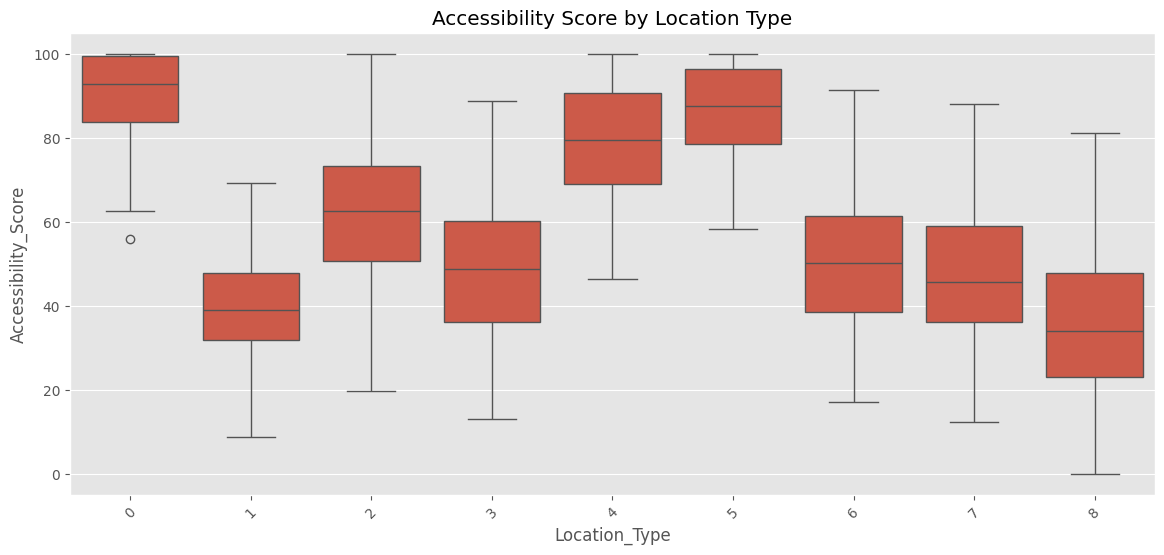

In [ ]:
plt.figure(figsize=(14,6))

sns.boxplot(
    x="Location_Type",
    y="Accessibility_Score",
    data=df
)

plt.xticks(rotation=45)
plt.title("Accessibility Score by Location Type")
plt.show()

**SECTION 14 ACCESSIBILITY SCORE VS CROWD LEVEL**

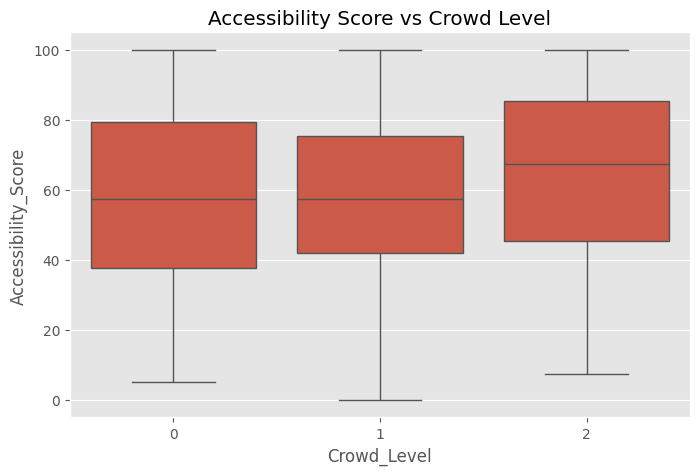

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Crowd_Level",
    y="Accessibility_Score",
    data=df
)
plt.title("Accessibility Score vs Crowd Level")
plt.show()

**SECTION 15 ACCESSIBILITY SCORE VS SAFETY**

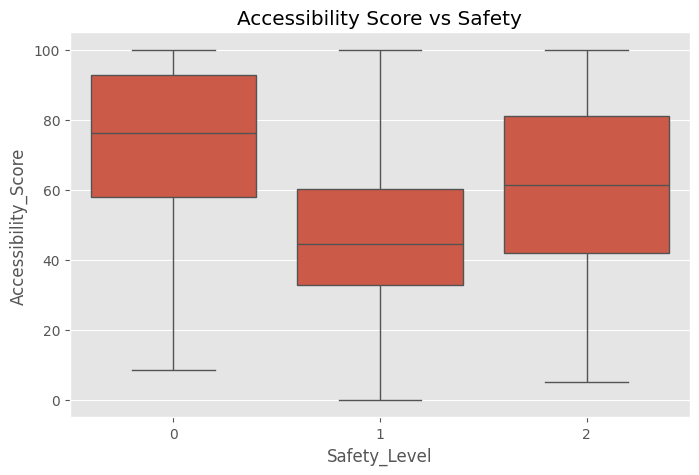

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Safety_Level",
    y="Accessibility_Score",
    data=df
)
plt.title("Accessibility Score vs Safety")
plt.show()

**SECTION 16 ACCESSIBILITY SCORE VS USER RATING**

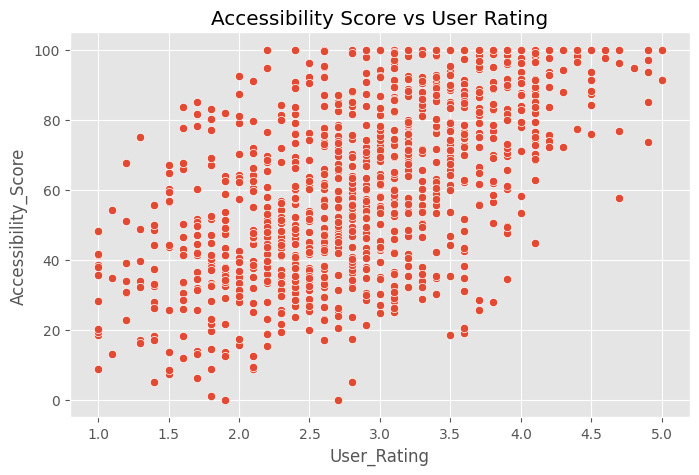

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="User_Rating",
    y="Accessibility_Score",
    data=df
)
plt.title("Accessibility Score vs User Rating")
plt.show()

**SECTION 17 CORRELATION HEATMAP**

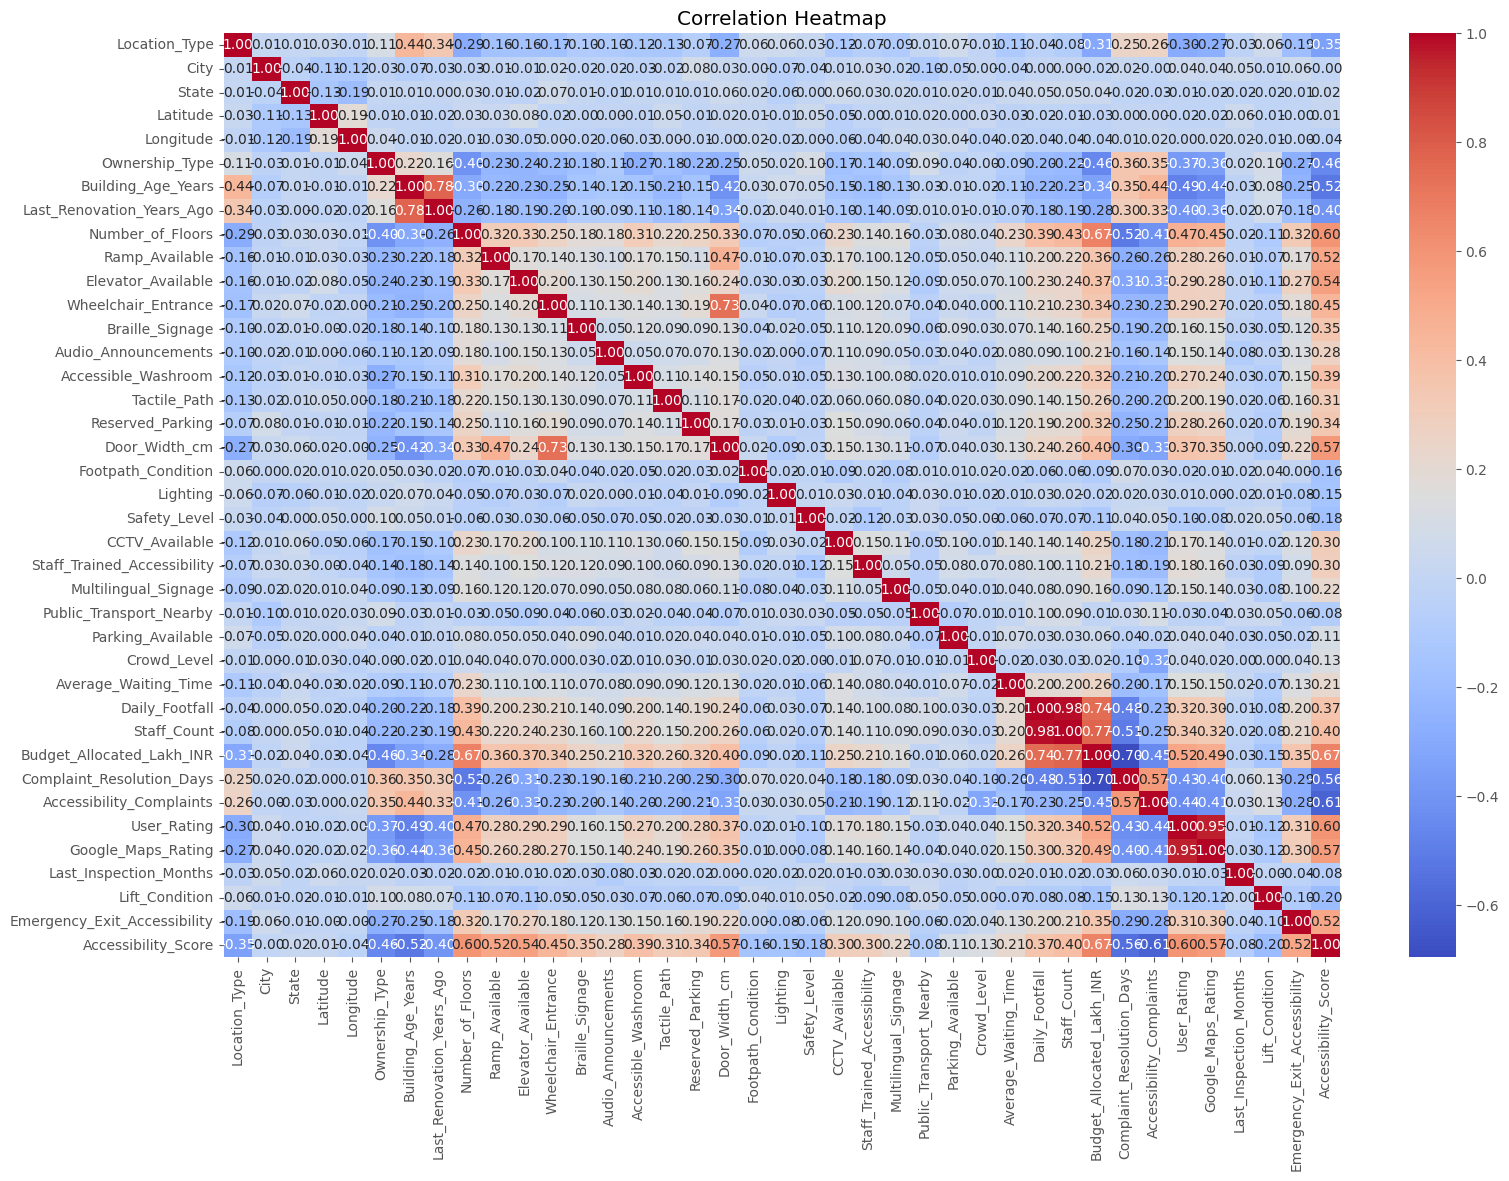

In [ ]:
numerical_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(18,12))

sns.heatmap(
    numerical_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

**SECTION 18 PAIR PLOT**

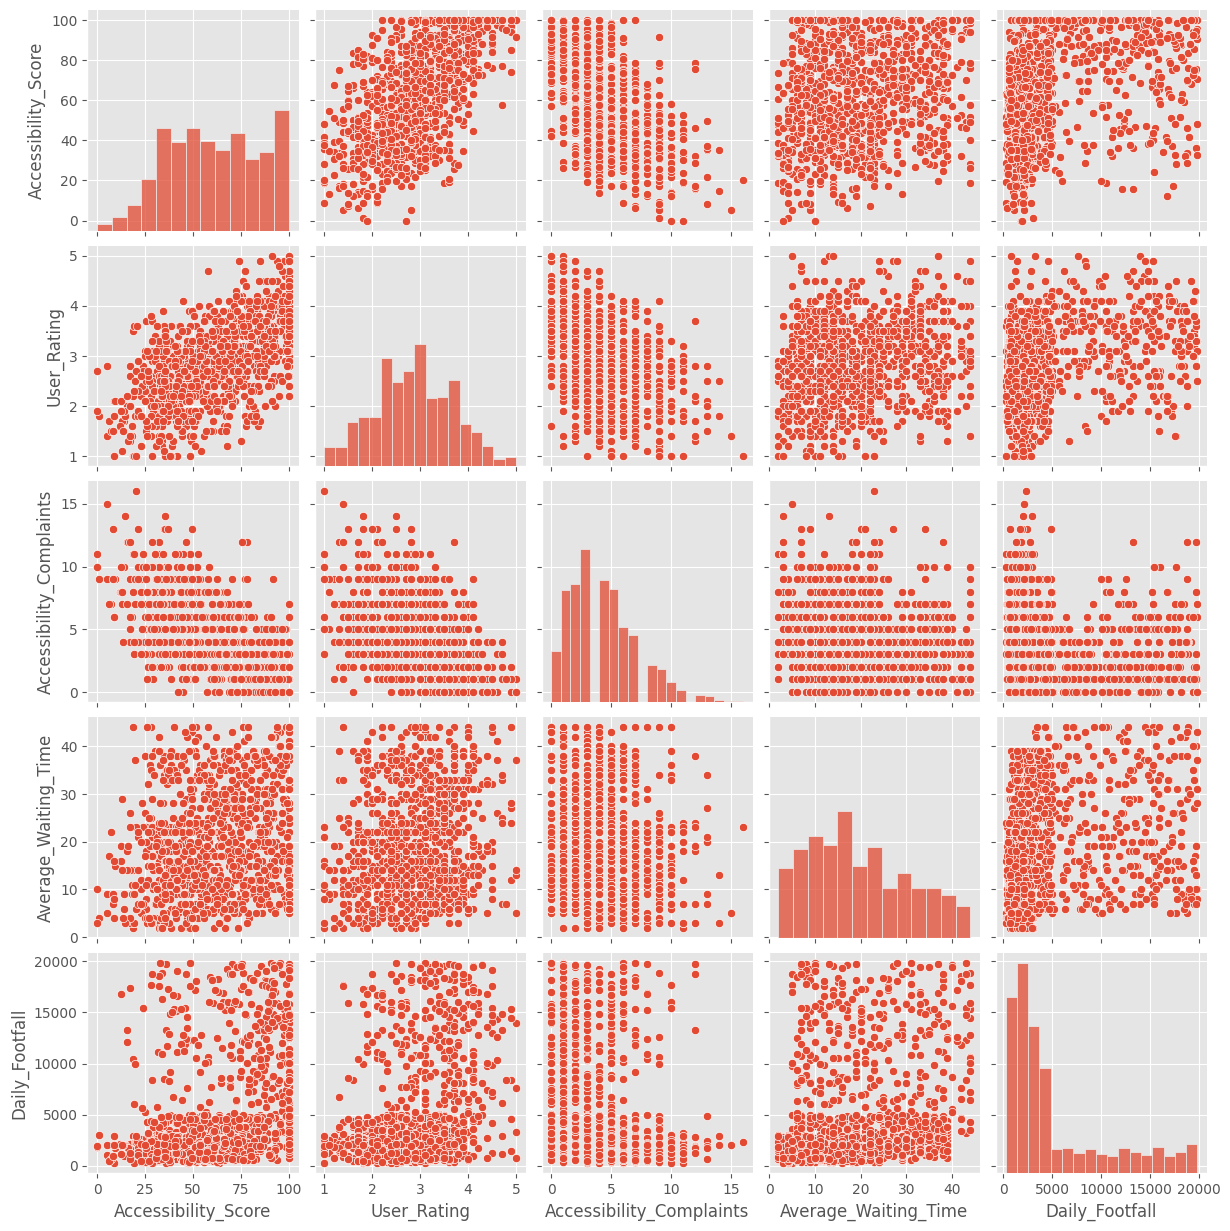

In [ ]:
selected = df[
    [
        "Accessibility_Score",
        "User_Rating",
        "Accessibility_Complaints",
        "Average_Waiting_Time",
        "Daily_Footfall"
    ]
]

sns.pairplot(selected)
plt.show()

**SECTION 19 NUMERICAL FEATURES DISTRIBUTION**

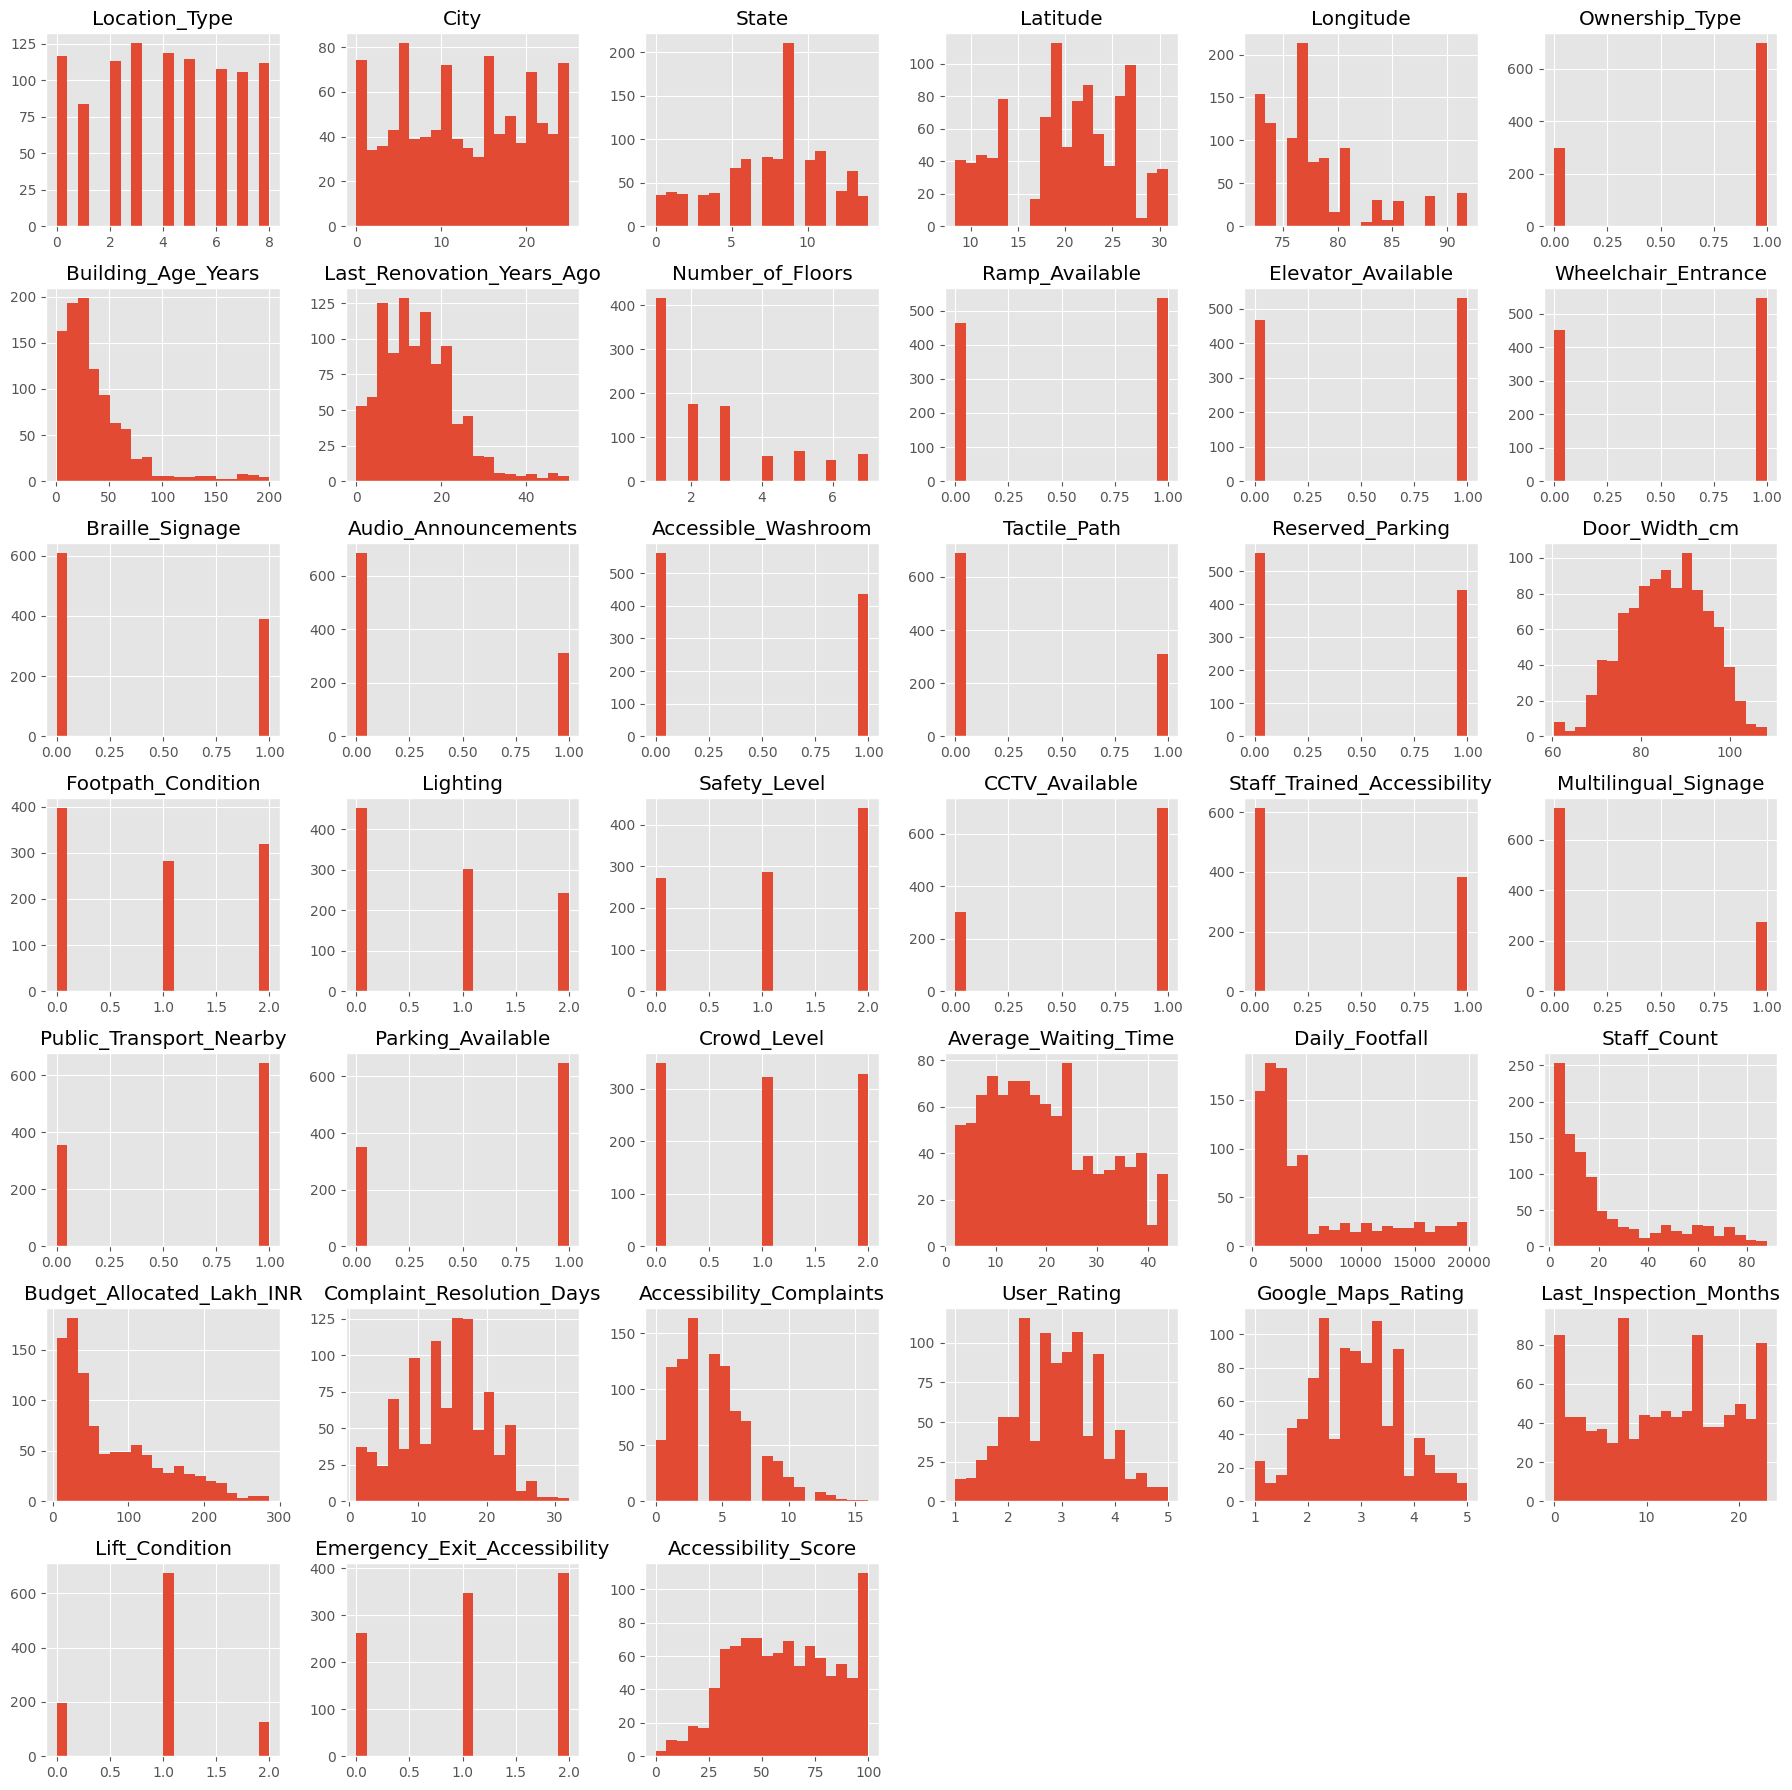

In [ ]:
numerical_columns = df.select_dtypes(include=np.number).columns

df[numerical_columns].hist(
    figsize=(18,18),
    bins=20
)
plt.tight_layout()
plt.show()

**SECTION 20 FINAL INSIGHT**

1. Most public locations have good accessibility scores.
2. Hospitals and malls generally have higher accessibility than older government buildings.
3. Higher crowd levels are associated with lower accessibility scores.
4. Better safety and lighting correspond to higher user ratings.
5. Accessibility complaints increase as accessibility scores decrease.
6. Strong correlations exist between accessibility features and the accessibility score.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 43 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Location_ID                   1000 non-null   object 
 1   Location_Name                 1000 non-null   object 
 2   Location_Type                 1000 non-null   int64  
 3   City                          1000 non-null   int64  
 4   State                         1000 non-null   int64  
 5   Latitude                      1000 non-null   float64
 6   Longitude                     1000 non-null   float64
 7   Ownership_Type                1000 non-null   int64  
 8   Building_Age_Years            1000 non-null   int64  
 9   Last_Renovation_Years_Ago     1000 non-null   float64
 10  Number_of_Floors              1000 non-null   int64  
 11  Ramp_Available                1000 non-null   int64  
 12  Elevator_Available            1000 non-null   int64  
 13  Whee

In [ ]:
df.head()

,Location_ID,Location_Name,Location_Type,City,State,Latitude,Longitude,Ownership_Type,Building_Age_Years,Last_Renovation_Years_Ago,...,Complaint_Resolution_Days,Accessibility_Complaints,User_Rating,Google_Maps_Rating,Last_Inspection_Months,Lift_Condition,Emergency_Exit_Accessibility,Accessibility_Score,Accessibility_Category,Improvement_Priority
0,LOC0001,Kolkata Botanical Garden,8,13,14,22.691764,88.446606,1,168,32.0,...,13.0,3,1.8,1.8,12.0,1,1,47.2,Poor,Medium
1,LOC0002,Hyderabad Municipal Office,3,8,12,17.236120,78.585714,1,57,12.0,...,12.0,3,1.9,1.8,15.0,1,0,36.1,Poor,High
2,LOC0003,Thane Government College,2,22,9,19.107785,73.081622,1,48,20.0,...,17.0,6,1.6,1.5,12.0,2,2,50.3,Poor,High
3,LOC0004,Nashik Green Park,6,18,9,19.849054,73.865693,1,38,22.0,...,21.0,5,3.2,3.1,12.0,1,1,38.2,Poor,High
4,LOC0005,Patna Domestic Airport,0,19,2,25.647041,85.202726,1,5,5.0,...,10.0,4,4.4,4.3,18.0,1,2,100.0,Excellent,Low


# **EXTRA**

**Add a Correlation with Target**

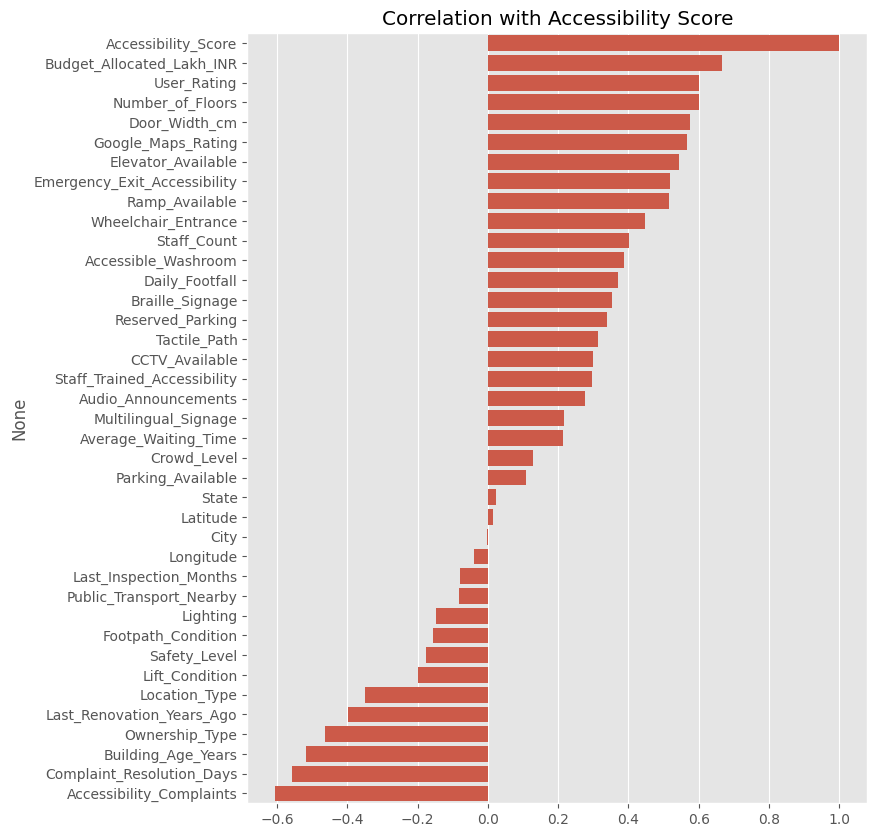

In [ ]:
corr = numerical_df.corr()["Accessibility_Score"].sort_values(ascending=False)

plt.figure(figsize=(8,10))
sns.barplot(
    x=corr.values,
    y=corr.index
)

plt.title("Correlation with Accessibility Score")
plt.show()

**Accessibility Category Pie Chart**

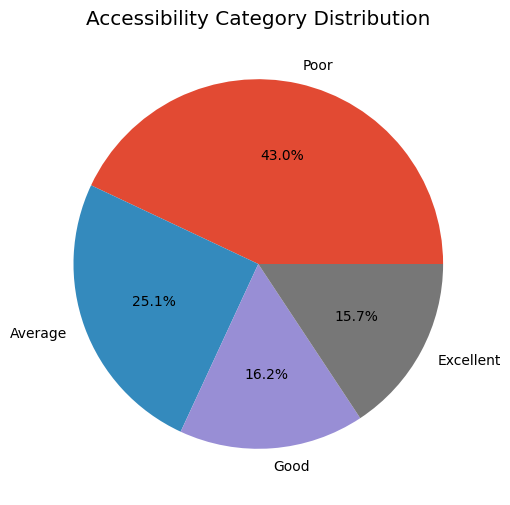

In [ ]:
df["Accessibility_Category"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.ylabel("")
plt.title("Accessibility Category Distribution")
plt.show()